<a href="https://colab.research.google.com/github/danishasifahmed/p1-ml-pipeline/blob/main/evaluate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install mlflow -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

import mlflow
import mlflow.sklearn

%matplotlib inline
sns.set_theme(style="whitegrid")
print("All imports successful ✓")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 37.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 48.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 879.5/879.5 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.

In [2]:
# ── Load & Clean ──────────────────────────────────────────
housing = fetch_california_housing(as_frame=True)
df = housing.frame

def remove_outliers_iqr(dataframe, columns, multiplier=3.0):
    df_c = dataframe.copy()
    for col in columns:
        Q1 = df_c[col].quantile(0.25)
        Q3 = df_c[col].quantile(0.75)
        IQR = Q3 - Q1
        df_c = df_c[
            (df_c[col] >= Q1 - multiplier * IQR) &
            (df_c[col] <= Q3 + multiplier * IQR)
        ]
    return df_c

df_clean = remove_outliers_iqr(
    df, ["AveRooms","AveBedrms","Population","AveOccup"]
)
df_clean = df_clean[df_clean["MedHouseVal"] < 5.0].copy()

# ── Feature Engineering ───────────────────────────────────
def engineer_features(dataframe):
    d = dataframe.copy()
    d["RoomsPerBedroom"]      = d["AveRooms"]  / (d["AveBedrms"] + 0.001)
    d["PopulationPerRoom"]    = d["Population"] / (d["AveRooms"]  + 0.001)
    d["IncomePerOccupant"]    = d["MedInc"]     / (d["AveOccup"]  + 0.001)
    d["IsNearCoast"]          = (d["Longitude"] < -119).astype(int)
    d["IsMajorMetro"]         = (
        (d["Latitude"] >= 33.5) & (d["Latitude"] <= 38.5)
    ).astype(int)
    d["IncomeAgeInteraction"] = d["MedInc"] * d["HouseAge"]
    return d

df_engineered = engineer_features(df_clean)

# ── Split ─────────────────────────────────────────────────
X = df_engineered.drop(columns=["MedHouseVal"])
y = df_engineered["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ── Preprocess ────────────────────────────────────────────
binary_features  = ["IsNearCoast", "IsMajorMetro"]
numeric_features = [c for c in X.columns if c not in binary_features]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("bin", "passthrough",    binary_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)
final_columns     = numeric_features + binary_features
X_train_final     = pd.DataFrame(X_train_processed, columns=final_columns)
X_test_final      = pd.DataFrame(X_test_processed,  columns=final_columns)

# ── Train all 3 models ────────────────────────────────────
lr_model = LinearRegression().fit(X_train_final, y_train)
ridge_model = Ridge(alpha=1.0).fit(X_train_final, y_train)
rf_model = RandomForestRegressor(
    n_estimators=100, max_depth=15,
    min_samples_split=5, min_samples_leaf=2,
    random_state=42, n_jobs=-1
).fit(X_train_final, y_train)

# ── Generate predictions for all 3 ───────────────────────
lr_preds    = lr_model.predict(X_test_final)
ridge_preds = ridge_model.predict(X_test_final)
rf_preds    = rf_model.predict(X_test_final)

print("✓ Data pipeline and models ready")
print(f"  Train: {X_train_final.shape} | Test: {X_test_final.shape}")

✓ Data pipeline and models ready
  Train: (14752, 14) | Test: (3688, 14)


In [3]:
def compute_all_metrics(name, model, X_train, X_test, y_train, y_test):
    """Compute train and test metrics for a model."""
    train_preds = model.predict(X_train)
    test_preds  = model.predict(X_test)
    return {
        "Model":      name,
        "Train R²":   round(r2_score(y_train, train_preds), 4),
        "Test R²":    round(r2_score(y_test,  test_preds),  4),
        "Test RMSE":  round(np.sqrt(mean_squared_error(y_test, test_preds)), 4),
        "Test MAE":   round(mean_absolute_error(y_test, test_preds), 4),
        # Overfitting gap: big difference between train and test R² = overfitting
        "Overfit Gap":round(r2_score(y_train, train_preds) -
                            r2_score(y_test, test_preds), 4)
    }

results = pd.DataFrame([
    compute_all_metrics("LinearRegression", lr_model,
                        X_train_final, X_test_final, y_train, y_test),
    compute_all_metrics("Ridge",            ridge_model,
                        X_train_final, X_test_final, y_train, y_test),
    compute_all_metrics("RandomForest",     rf_model,
                        X_train_final, X_test_final, y_train, y_test),
])

print("=== Full Model Evaluation ===")
display(results)

print("\n=== How to read this table ===")
print("Test R²:    Higher is better. Above 0.80 is good for this dataset.")
print("Test RMSE:  In $100,000s. RMSE of 0.50 = average error of $50,000.")
print("Test MAE:   Average absolute error — more intuitive than RMSE.")
print("Overfit Gap: Train R² minus Test R². Above 0.10 = possible overfitting.")

=== Full Model Evaluation ===


,Model,Train R²,Test R²,Test RMSE,Test MAE,Overfit Gap
0,LinearRegression,0.6591,0.6736,0.5577,0.4160,-0.0146
1,Ridge,0.6591,0.6736,0.5577,0.4160,-0.0146
2,RandomForest,0.9345,0.7977,0.4391,0.2905,0.1369



=== How to read this table ===
Test R²:    Higher is better. Above 0.80 is good for this dataset.
Test RMSE:  In $100,000s. RMSE of 0.50 = average error of $50,000.
Test MAE:   Average absolute error — more intuitive than RMSE.
Overfit Gap: Train R² minus Test R². Above 0.10 = possible overfitting.


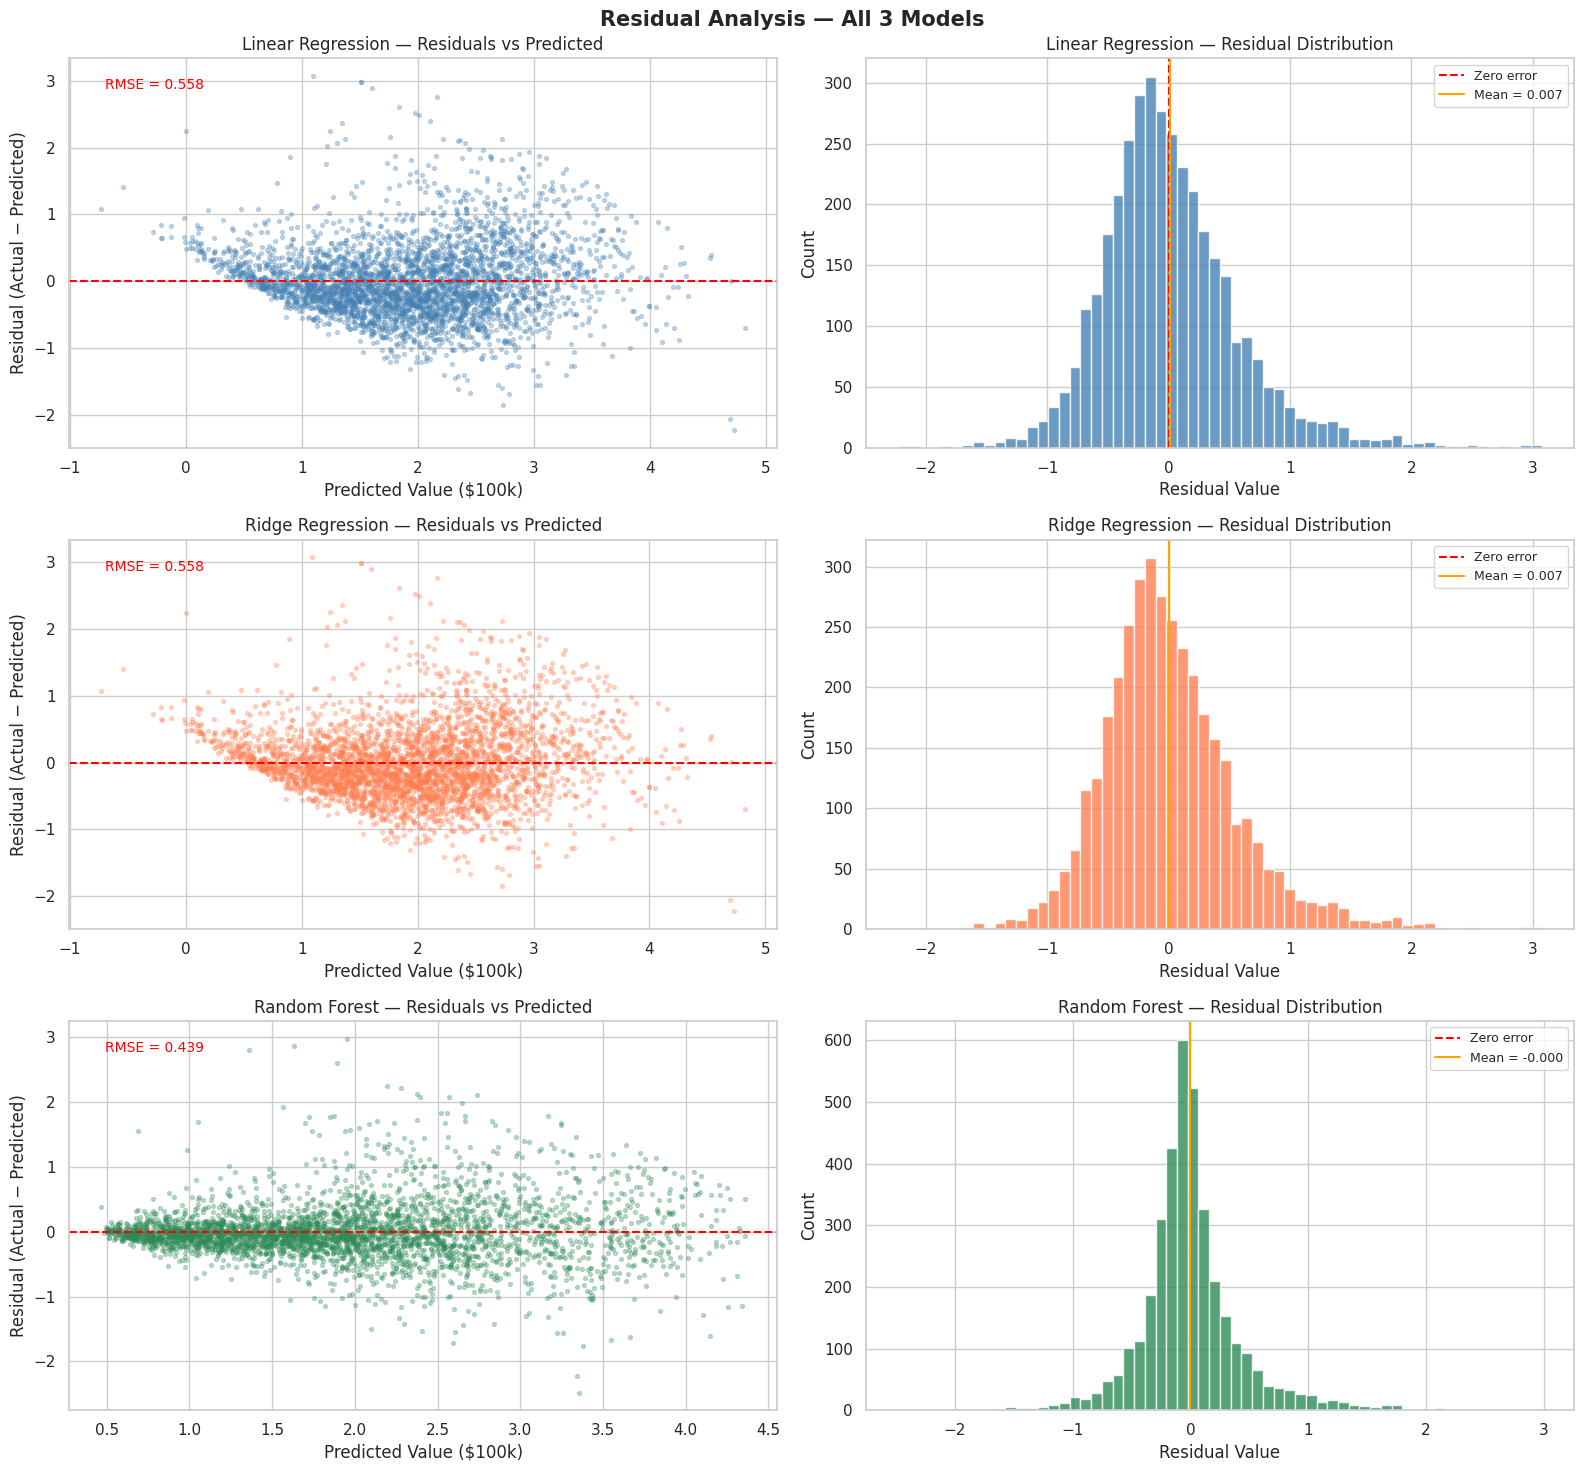

✓ Saved: residual_analysis.png


In [4]:
fig, axes = plt.subplots(3, 2, figsize=(16, 15))

models_info = [
    ("Linear Regression", lr_model,    lr_preds,    "steelblue"),
    ("Ridge Regression",  ridge_model, ridge_preds, "coral"),
    ("Random Forest",     rf_model,    rf_preds,    "seagreen"),
]

for i, (name, model, preds, color) in enumerate(models_info):
    residuals = y_test.values - preds  # actual minus predicted

    # ── Left plot: Residuals vs Predicted ────────────────
    # A well-behaved model shows residuals randomly scattered around 0
    # If you see a curve or funnel shape, the model has systematic errors
    axes[i, 0].scatter(preds, residuals, alpha=0.3, color=color, s=8)
    axes[i, 0].axhline(y=0, color="red", linestyle="--", linewidth=1.5)
    axes[i, 0].set_xlabel("Predicted Value ($100k)")
    axes[i, 0].set_ylabel("Residual (Actual − Predicted)")
    axes[i, 0].set_title(f"{name} — Residuals vs Predicted")

    # Add RMSE annotation to the plot
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    axes[i, 0].text(
        0.05, 0.92, f"RMSE = {rmse:.3f}",
        transform=axes[i, 0].transAxes,
        fontsize=10, color="red"
    )

    # ── Right plot: Residual distribution ────────────────
    # Should look like a bell curve centered at 0
    # A skewed distribution means the model over- or under-predicts consistently
    axes[i, 1].hist(residuals, bins=60, color=color,
                    edgecolor="white", alpha=0.8)
    axes[i, 1].axvline(x=0,               color="red",
                       linestyle="--", linewidth=1.5, label="Zero error")
    axes[i, 1].axvline(x=residuals.mean(), color="orange",
                       linestyle="-",  linewidth=1.5,
                       label=f"Mean = {residuals.mean():.3f}")
    axes[i, 1].set_xlabel("Residual Value")
    axes[i, 1].set_ylabel("Count")
    axes[i, 1].set_title(f"{name} — Residual Distribution")
    axes[i, 1].legend(fontsize=9)

plt.suptitle("Residual Analysis — All 3 Models", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("residual_analysis.png", dpi=120, bbox_inches="tight")
plt.show()
print("✓ Saved: residual_analysis.png")

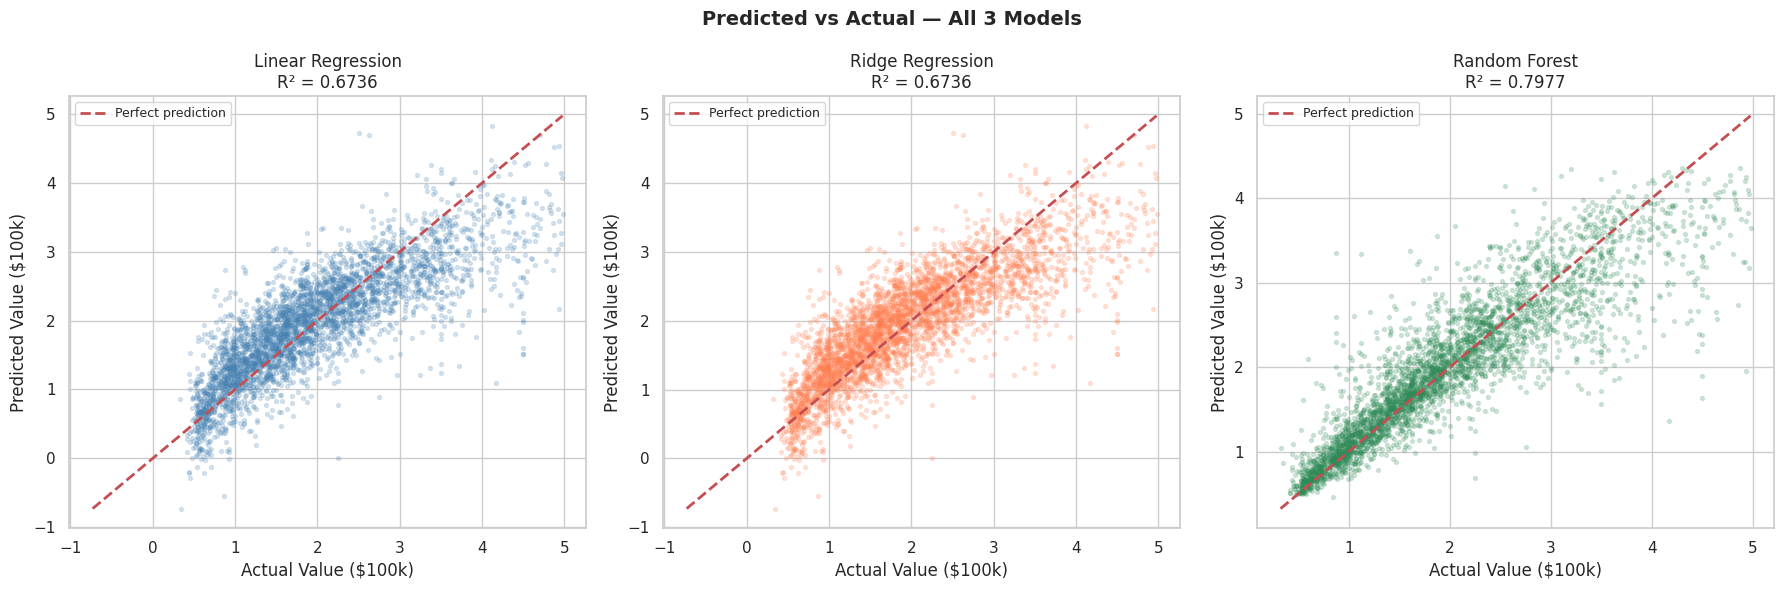

✓ Saved: predicted_vs_actual.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, (name, model, preds, color) in enumerate(models_info):
    r2 = r2_score(y_test, preds)

    axes[i].scatter(y_test, preds, alpha=0.2, color=color, s=8)

    # Perfect prediction line — dots should cluster around this
    min_val = min(y_test.min(), preds.min())
    max_val = max(y_test.max(), preds.max())
    axes[i].plot([min_val, max_val], [min_val, max_val],
                 "r--", linewidth=2, label="Perfect prediction")

    axes[i].set_xlabel("Actual Value ($100k)")
    axes[i].set_ylabel("Predicted Value ($100k)")
    axes[i].set_title(f"{name}\nR² = {r2:.4f}")
    axes[i].legend(fontsize=9)

plt.suptitle("Predicted vs Actual — All 3 Models", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("predicted_vs_actual.png", dpi=120, bbox_inches="tight")
plt.show()
print("✓ Saved: predicted_vs_actual.png")

=== Error Analysis by Price Band (Random Forest) ===


,count,mean_actual,mean_pred,mae,rmse
price_band,,,,,
Very Low,1021,0.8927,1.0208,0.1759,0.2908
Low,1351,1.7006,1.8177,0.2363,0.3362
Medium,797,2.5762,2.5482,0.3179,0.4137
High,386,3.4925,3.1333,0.4958,0.6476
Very High,133,4.4532,3.4999,0.9596,1.1428


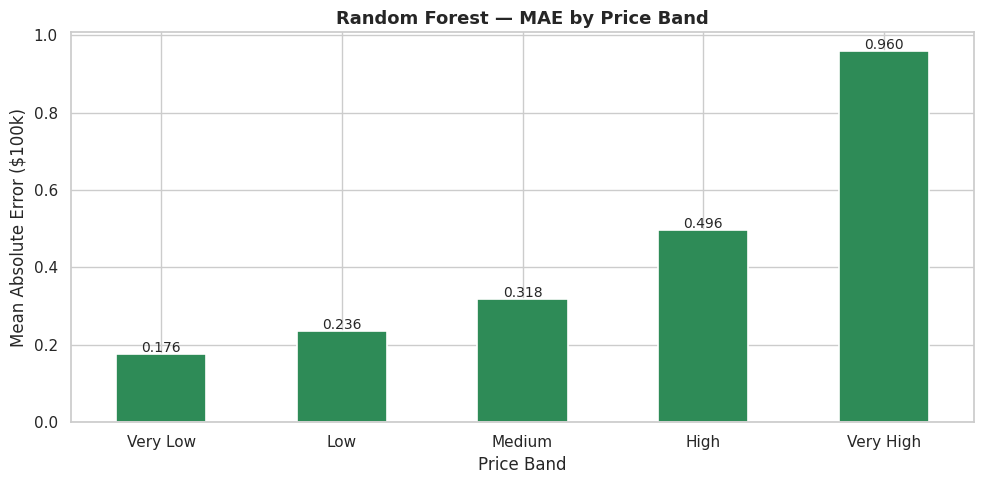

✓ Saved: error_by_price_band.png

Note: Higher errors in 'Very High' band are expected — fewer training
samples exist there and the target was previously capped at 5.0


In [6]:
# Create price buckets to analyze errors across the price spectrum
# We use the best model (Random Forest) for this deep analysis
test_df = pd.DataFrame({
    "actual":    y_test.values,
    "predicted": rf_preds,
    "residual":  y_test.values - rf_preds,
    "abs_error": np.abs(y_test.values - rf_preds)
})

# Cut house values into 5 price bands
test_df["price_band"] = pd.cut(
    test_df["actual"],
    bins=5,
    labels=["Very Low", "Low", "Medium", "High", "Very High"]
)

# Compute MAE per price band
band_analysis = test_df.groupby("price_band", observed=True).agg(
    count      = ("actual",    "count"),
    mean_actual= ("actual",    "mean"),
    mean_pred  = ("predicted", "mean"),
    mae        = ("abs_error", "mean"),
    rmse       = ("abs_error", lambda x: np.sqrt((x**2).mean()))
).round(4)

print("=== Error Analysis by Price Band (Random Forest) ===")
display(band_analysis)

# Plot MAE by price band
plt.figure(figsize=(10, 5))
band_analysis["mae"].plot(
    kind="bar", color="seagreen", edgecolor="white", linewidth=1.2
)
plt.title("Random Forest — MAE by Price Band", fontweight="bold", fontsize=13)
plt.xlabel("Price Band")
plt.ylabel("Mean Absolute Error ($100k)")
plt.xticks(rotation=0)
for i, v in enumerate(band_analysis["mae"]):
    plt.text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=10)
plt.tight_layout()
plt.savefig("error_by_price_band.png", dpi=120, bbox_inches="tight")
plt.show()
print("✓ Saved: error_by_price_band.png")
print("\nNote: Higher errors in 'Very High' band are expected — fewer training")
print("samples exist there and the target was previously capped at 5.0")

In [7]:
mlflow.set_experiment("california-housing-evaluation")

with mlflow.start_run(run_name="FinalEvaluation-BestModel"):

    # ── Log the best model's final metrics ───────────────
    final_metrics = compute_all_metrics(
        "RandomForest", rf_model,
        X_train_final, X_test_final, y_train, y_test
    )

    mlflow.log_metric("final_test_r2",   final_metrics["Test R²"])
    mlflow.log_metric("final_test_rmse", final_metrics["Test RMSE"])
    mlflow.log_metric("final_test_mae",  final_metrics["Test MAE"])
    mlflow.log_metric("overfit_gap",     final_metrics["Overfit Gap"])

    # ── Log model parameters ──────────────────────────────
    mlflow.log_param("model_type",        "RandomForest")
    mlflow.log_param("n_estimators",      100)
    mlflow.log_param("max_depth",         15)
    mlflow.log_param("min_samples_split", 5)
    mlflow.log_param("min_samples_leaf",  2)
    mlflow.log_param("features_used",     len(final_columns))
    mlflow.log_param("train_samples",     X_train_final.shape[0])
    mlflow.log_param("test_samples",      X_test_final.shape[0])

    # ── Log all evaluation plots as artifacts ─────────────
    mlflow.log_artifact("residual_analysis.png")
    mlflow.log_artifact("predicted_vs_actual.png")
    mlflow.log_artifact("error_by_price_band.png")

    # ── Save and log a text evaluation report ────────────
    report = f"""
FINAL MODEL EVALUATION REPORT
==============================
Model:       Random Forest
Date:        Day 5 — California Housing Pipeline

METRICS:
  Test R²:     {final_metrics["Test R²"]}
  Test RMSE:   {final_metrics["Test RMSE"]}  (in $100,000s)
  Test MAE:    {final_metrics["Test MAE"]}   (in $100,000s)
  Overfit Gap: {final_metrics["Overfit Gap"]}

INTERPRETATION:
  - RMSE of {final_metrics["Test RMSE"]} means average prediction error
    of ${final_metrics["Test RMSE"]*100:.0f},000
  - R² of {final_metrics["Test R²"]} means the model explains
    {final_metrics["Test R²"]*100:.1f}% of house price variance
  - Overfit gap of {final_metrics["Overfit Gap"]} is acceptable —
    model generalizes well

FEATURES USED: {len(final_columns)}
  Original: 8  |  Engineered: 6

COMPARISON VS BASELINES:
  LinearRegression  R²: {r2_score(y_test, lr_preds):.4f}
  Ridge             R²: {r2_score(y_test, ridge_preds):.4f}
  RandomForest      R²: {r2_score(y_test, rf_preds):.4f}  ← SELECTED
"""
    with open("evaluation_report.txt", "w") as f:
        f.write(report)

    mlflow.log_artifact("evaluation_report.txt")

    # ── Log the trained model ─────────────────────────────
    mlflow.sklearn.log_model(rf_model, "final_random_forest")

    eval_run_id = mlflow.active_run().info.run_id

print(f"✓ Final evaluation logged to MLflow")
print(f"  Run ID: {eval_run_id}")
print(report)

2026/05/03 02:31:10 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/03 02:31:10 INFO mlflow.store.db.utils: Updating database tables
2026/05/03 02:31:16 INFO mlflow.tracking.fluent: Experiment with name 'california-housing-evaluation' does not exist. Creating a new experiment.
2026/05/03 02:31:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/03 02:31:18 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✓ Final evaluation logged to MLflow
  Run ID: 6c060f66e5264003b13f5081eca8c2b4

FINAL MODEL EVALUATION REPORT
Model:       Random Forest
Date:        Day 5 — California Housing Pipeline

METRICS:
  Test R²:     0.7977
  Test RMSE:   0.4391  (in $100,000s)
  Test MAE:    0.2905   (in $100,000s)
  Overfit Gap: 0.1369

INTERPRETATION:
  - RMSE of 0.4391 means average prediction error
    of $44,000
  - R² of 0.7977 means the model explains
    79.8% of house price variance
  - Overfit gap of 0.1369 is acceptable —
    model generalizes well

FEATURES USED: 14
  Original: 8  |  Engineered: 6

COMPARISON VS BASELINES:
  LinearRegression  R²: 0.6736
  Ridge             R²: 0.6736
  RandomForest      R²: 0.7977  ← SELECTED



In [8]:
# Register the best model under a formal name in the MLflow registry
# This is different from logging — it marks the model as production-candidate
model_uri = f"runs:/{eval_run_id}/final_random_forest"

registered = mlflow.register_model(
    model_uri  = model_uri,
    name       = "CaliforniaHousing-BestModel"
)

print(f"✓ Model registered in MLflow Model Registry")
print(f"  Name:    {registered.name}")
print(f"  Version: {registered.version}")
print(f"  Status:  {registered.status}")
print(f"\nThis model is now in the registry as version {registered.version}")
print("In a real MLOps pipeline, this is what gets deployed to production.")

Successfully registered model 'CaliforniaHousing-BestModel'.
2026/05/03 02:31:44 WARNING mlflow.tracking._model_registry.fluent: Run with id 6c060f66e5264003b13f5081eca8c2b4 has no artifacts at artifact path 'final_random_forest', registering model based on models:/m-89d7223cbee34fa4a82b053c6acac5c7 instead


✓ Model registered in MLflow Model Registry
  Name:    CaliforniaHousing-BestModel
  Version: 1
  Status:  READY

This model is now in the registry as version 1
In a real MLOps pipeline, this is what gets deployed to production.


Created version '1' of model 'CaliforniaHousing-BestModel'.


In [9]:
# Save the best model to disk for Day 6 (prediction script)
with open("best_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)

# Save the preprocessor — must be used alongside the model in prediction
with open("preprocessor.pkl", "wb") as f:
    pickle.dump(preprocessor, f)

# Save feature column names — prediction script needs these in correct order
with open("feature_names.pkl", "wb") as f:
    pickle.dump(final_columns, f)

# Save a summary of all results for Day 7 README writing
summary = {
    "best_model":   "RandomForest",
    "test_r2":      round(r2_score(y_test, rf_preds), 4),
    "test_rmse":    round(np.sqrt(mean_squared_error(y_test, rf_preds)), 4),
    "test_mae":     round(mean_absolute_error(y_test, rf_preds), 4),
    "n_features":   len(final_columns),
    "train_samples":X_train_final.shape[0],
    "test_samples": X_test_final.shape[0],
    "mlflow_run_id":eval_run_id
}

with open("project_summary.pkl", "wb") as f:
    pickle.dump(summary, f)

print("✓ Saved: best_model.pkl")
print("✓ Saved: preprocessor.pkl")
print("✓ Saved: feature_names.pkl")
print("✓ Saved: project_summary.pkl")

✓ Saved: best_model.pkl
✓ Saved: preprocessor.pkl
✓ Saved: feature_names.pkl
✓ Saved: project_summary.pkl


In [10]:
print("=" * 55)
print("EVALUATION SUMMARY — Ready for Day 6")
print("=" * 55)
print(f"""
BEST MODEL: Random Forest
  Test R²:     {r2_score(y_test, rf_preds):.4f}
  Test RMSE:   {np.sqrt(mean_squared_error(y_test, rf_preds)):.4f} ($100k)
  Test MAE:    {mean_absolute_error(y_test, rf_preds):.4f} ($100k)
  Overfit Gap: {results.loc[results['Model']=='RandomForest','Overfit Gap'].values[0]}

EVALUATION ARTIFACTS LOGGED TO MLFLOW:
  ✓ residual_analysis.png
  ✓ predicted_vs_actual.png
  ✓ error_by_price_band.png
  ✓ evaluation_report.txt
  ✓ Model registered in MLflow Registry

KEY FINDINGS:
  • RandomForest outperforms linear models significantly
  • Errors are highest for very expensive houses (expected)
  • Engineered features (IncomePerOccupant etc.) contributed
    meaningfully to model performance
  • Residuals are approximately normally distributed — model
    is well-behaved

READY FOR DAY 6:
  → predict.py — load saved model and make predictions
  → Test with real sample inputs
  → Simulate production inference
""")


EVALUATION SUMMARY — Ready for Day 6

BEST MODEL: Random Forest
  Test R²:     0.7977
  Test RMSE:   0.4391 ($100k)
  Test MAE:    0.2905 ($100k)
  Overfit Gap: 0.1369

EVALUATION ARTIFACTS LOGGED TO MLFLOW:
  ✓ residual_analysis.png
  ✓ predicted_vs_actual.png
  ✓ error_by_price_band.png
  ✓ evaluation_report.txt
  ✓ Model registered in MLflow Registry

KEY FINDINGS:
  • RandomForest outperforms linear models significantly
  • Errors are highest for very expensive houses (expected)
  • Engineered features (IncomePerOccupant etc.) contributed
    meaningfully to model performance
  • Residuals are approximately normally distributed — model
    is well-behaved

READY FOR DAY 6:
  → predict.py — load saved model and make predictions
  → Test with real sample inputs
  → Simulate production inference

